<a href="https://colab.research.google.com/github/THEWACHER1103/Churn_/blob/main/CHURN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn

La retención de clientes es un factor clave en la rentabilidad de cualquier empresa, ya que el costo de adquisición de nuevos clientes suele ser significativamente mayor que el de mantener los existentes.

En este proyecto se desarrolla un modelo de machine learning orientado a predecir la probabilidad de churn, entendiendo churn como la pérdida o abandono del cliente. A través del análisis de variables comportamentales y transaccionales, se busca identificar clientes en riesgo y habilitar estrategias proactivas de retención.


## Descripcion de Variables.
Variable objetivo:

* 1 = Churn (Cliente con posibilidad de abandono)
* 0 = No Churn (Cliente retenido)

* gender = Género del cliente (Male / Female)

* SeniorCitizen = Indica si el cliente es adulto mayor (1 = Sí, 0 = No)

* Partner = Si el cliente tiene pareja (Yes / No)

* Dependents = Si el cliente tiene dependientes (Yes / No)

* tenure = Tiempo (en meses) que el cliente lleva con la empresa.

* PhoneService = Si tiene servicio telefónico

* MultipleLines = Si tiene múltiples líneas telefónicas

* InternetService = Tipo de servicio de internet (DSL/Fiber optic /No)

* OnlineSecurity = Seguridad en línea

* OnlineBackup = Respaldo en la nube

* DeviceProtection = Protección de dispositivos

* TechSupport = Soporte técnico

* StreamingTV = Servicio de TV

* StreamingMovies = Servicio de películas

* Contract = Tipo de contrato. (Month-to-month /One year /Two year)

* PaperlessBilling = Facturación digital.

* PaymentMethod =Método de pago. (Electronic check / Mailed check / Bank transfer / Credit card)

* MonthlyCharges = Cargo mensual del cliente

* TotalCharges = Total pagado por el cliente



## Las variables incluyen características demográficas, servicios contratados, tipo de contrato y comportamiento de facturación, lo que permite analizar el churn desde múltiples dimensiones: comportamiento del cliente, nivel de engagement y factores económicos.

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import seaborn as sns

In [34]:
df = pd.read_csv('train.csv')
df.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [35]:
print(f"{df.info()}")
print('*=' * 30)
print(f"{df.isna().sum()}")
print('*=' * 30)
print(f"{df.isnull().sum()}")
print('*='*30)
print(f"{df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

* En el DataSet no existen Null's y ni Nan, tenemos muchas variables discretas no numericas las mismas requeriran transformacion, algunas binarias.

# Iniciando EDA

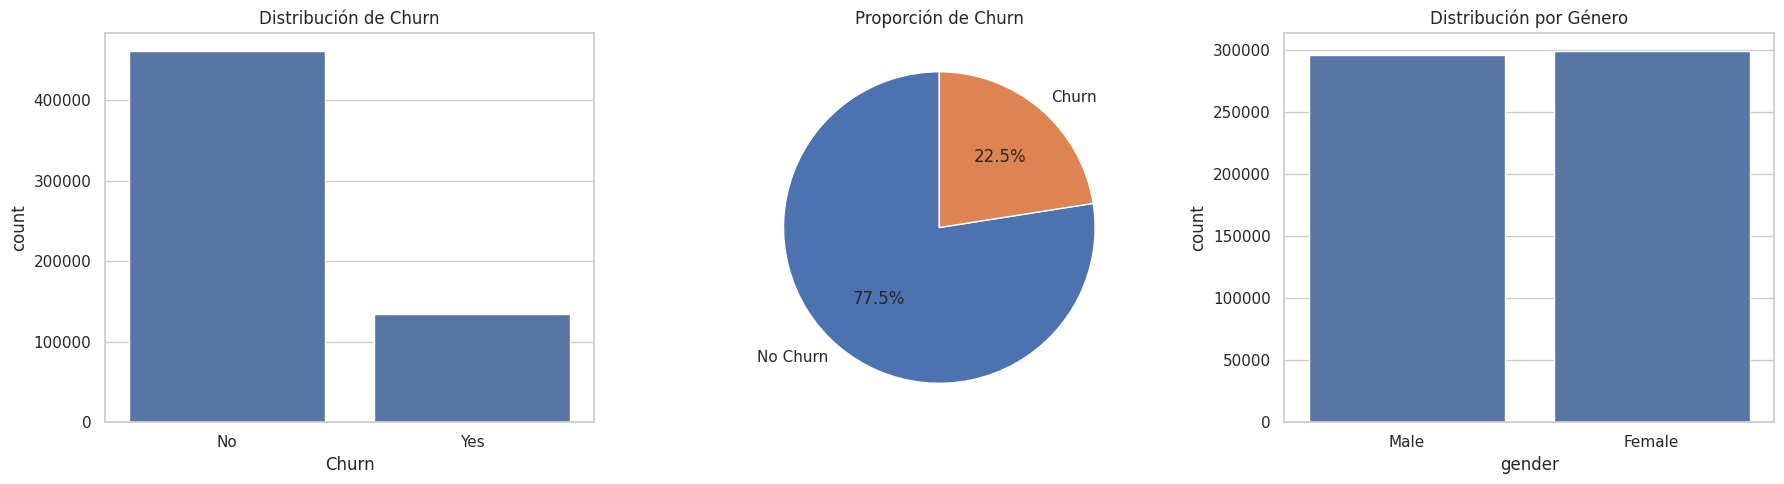

Churn
No     460377
Yes    133817
Name: count, dtype: int64
******************************
gender
Female    50.276172
Male      49.723828
Name: proportion, dtype: float64


In [36]:
sns.set(style="whitegrid")
# Crear figura con 3 subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Churn
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Distribución de Churn')


# Pie Chart (Churn)
churn_counts = df['Churn'].value_counts()
axes[1].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción de Churn')


# Género

sns.countplot(x='gender', data=df, ax=axes[2])
#axes[2].set_yscale('log')
axes[2].set_title('Distribución por Género')

# Ajustar espacios
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print('**'*15)
print(df['gender'].value_counts(normalize=True)*100)

* El dataset presenta desbalance (X% churn vs Y% no churn), lo cual deberá considerarse en el modelado.

# Distribucion de Variables Numericas.

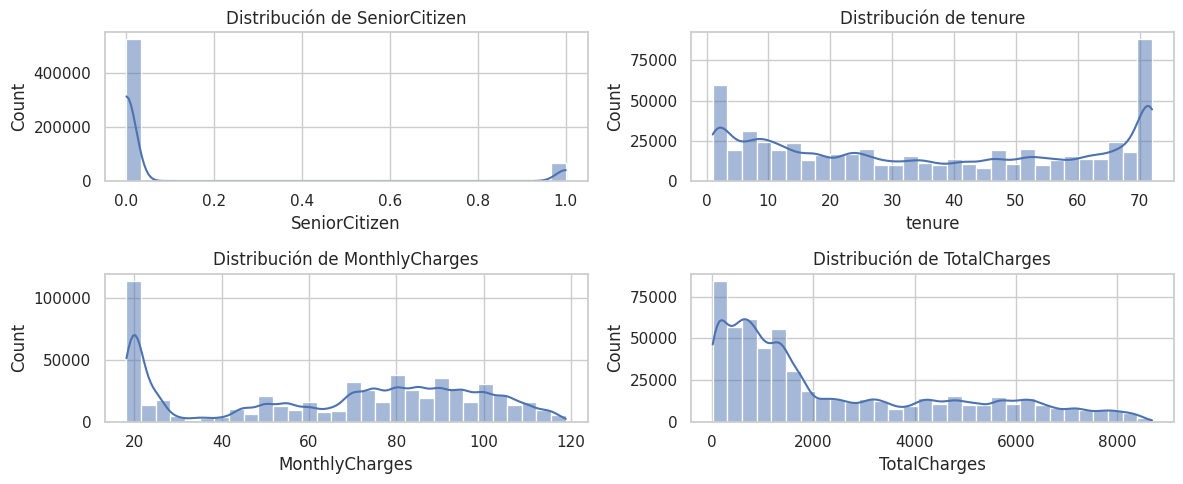

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12,5))

numerical_col = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

for i, col in enumerate(numerical_col):
    row = i // 2
    col_idx = i % 2

    sns.histplot(df[col], bins=30, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Observaciones Variables Numericas:

* La variable **SeniorCitizen** es una variable binaria, la cual indica que tenemos una poblacion en su mayoria joven.

* En **MonthlyCharges** confirmo la presencia de algunos bayes y Outliers, podria monstrar algun patron de subcripciones aumento de subscripciones en meses especificos.

* En **TotalCharges** se muestra una grafica decreciente con una fuerte concentracion de 0 a 1900 USD, cabe destacar que esta variable es medida en USD, tambien podria indicar que algunos clientes se atrasan levemente.

* En **Ternure** confirmo la existencia de Outliers los mismos indican una retencion balanceada por clientes viejos mostrando clientes que tienen mas de 70 meses con el servicio contratado, pero tambien muestra una gran masa de clientes que son nuevos y se tendria que buscar los puntos fuertes para hacer que duren en el tiempo.

# Distribucion de Variables Categoricas.

In [38]:
categorical_cols= df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["churn", "gender"]]

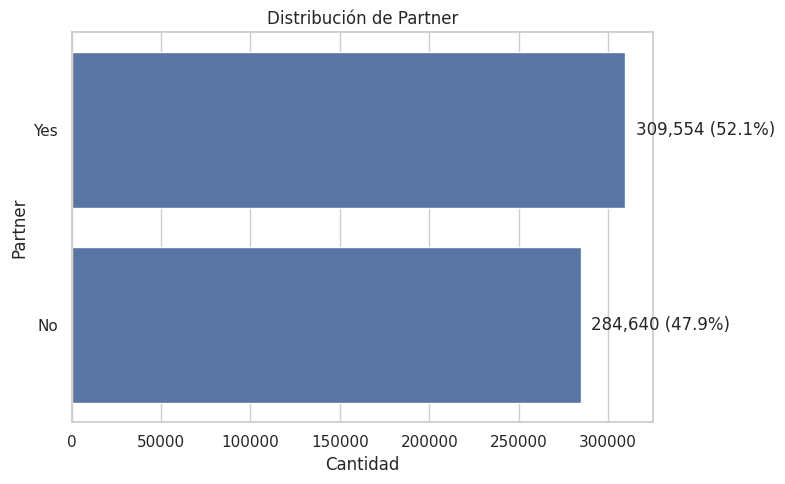

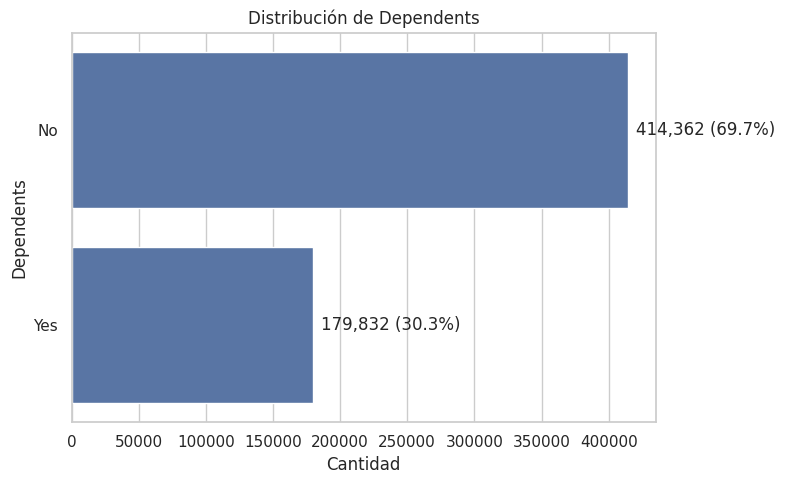

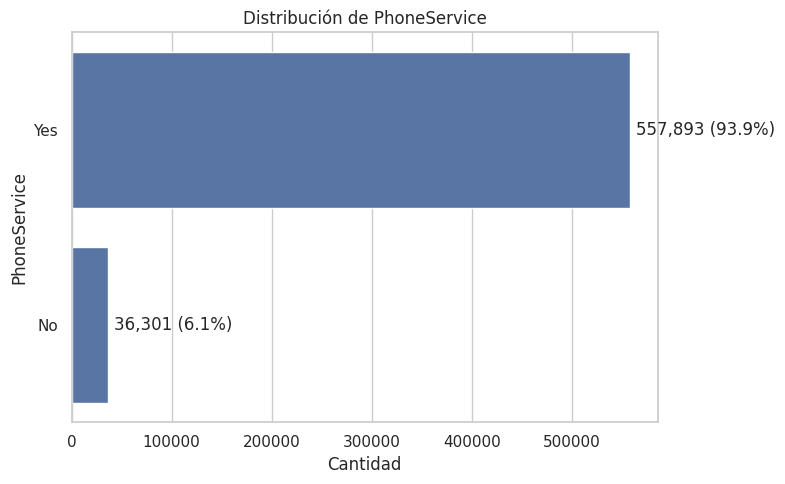

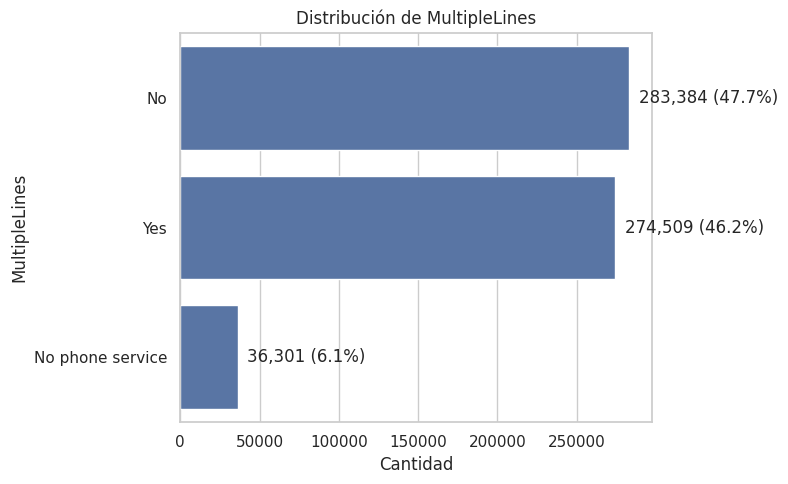

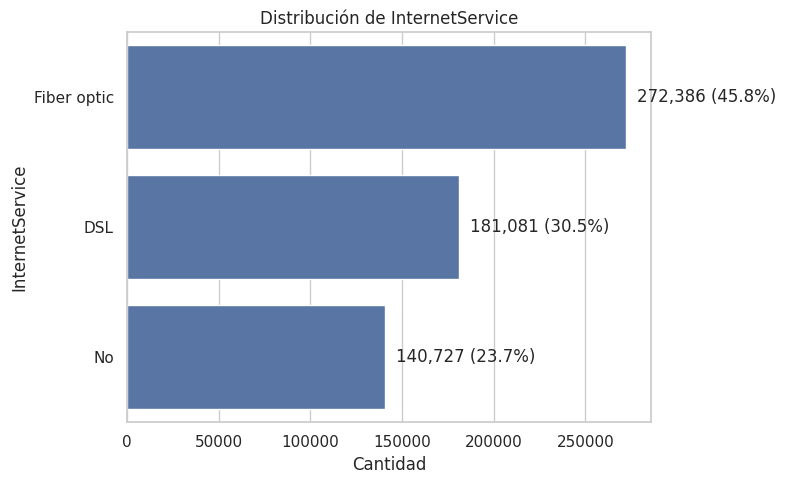

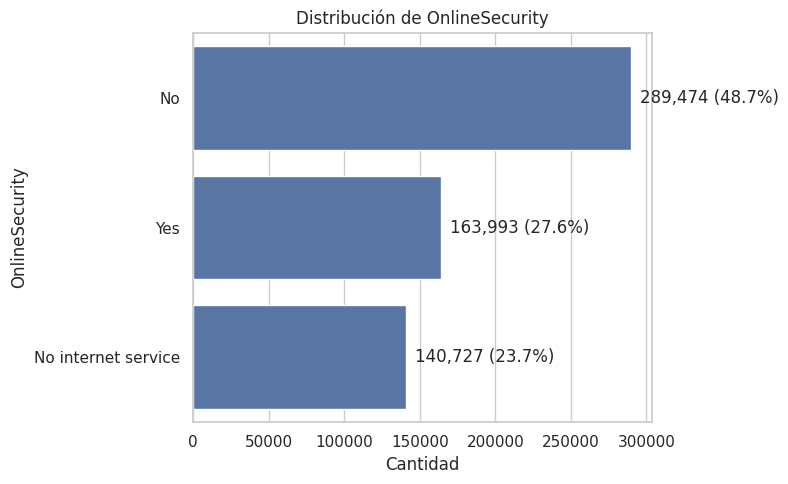

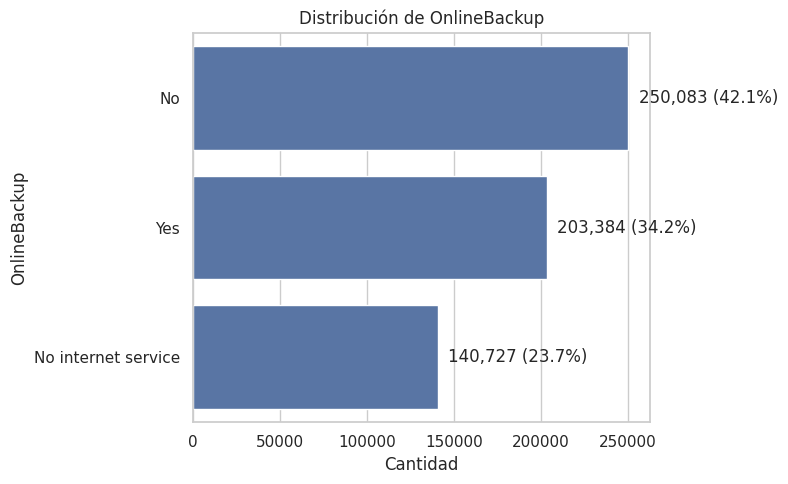

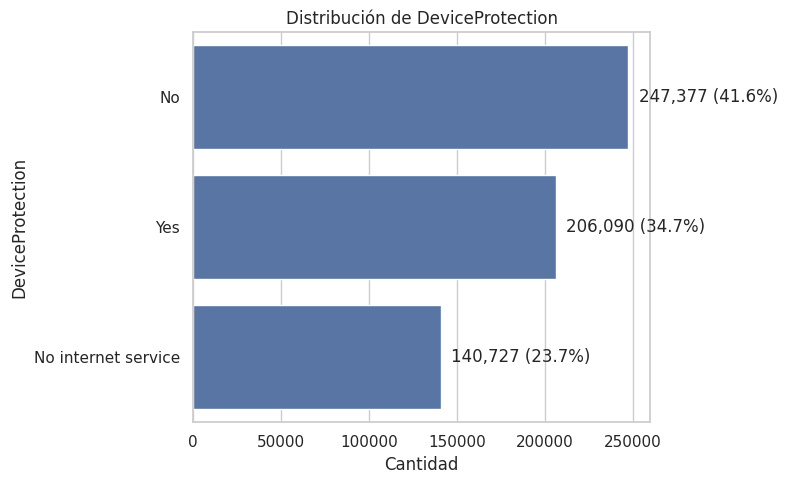

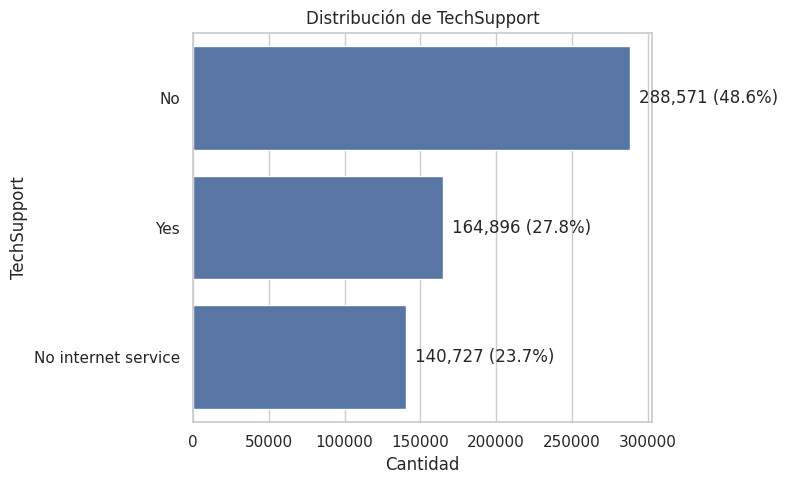

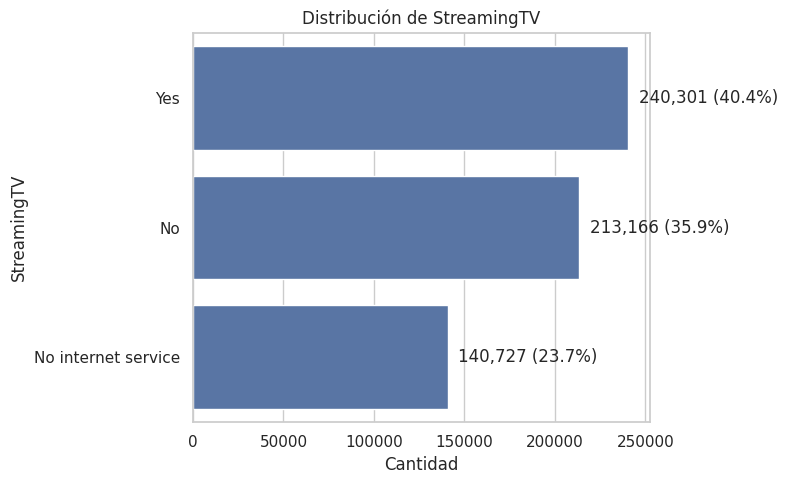

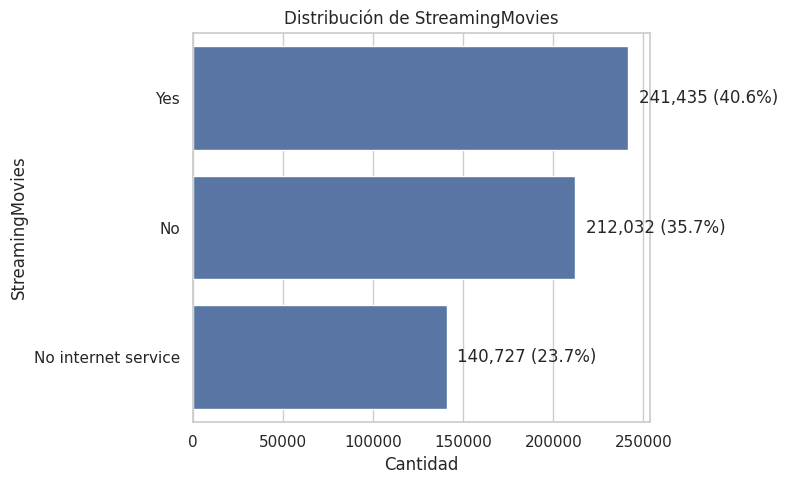

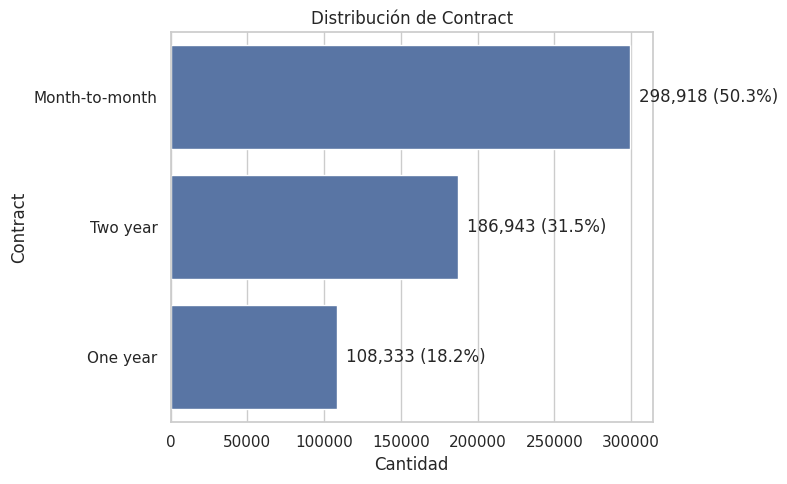

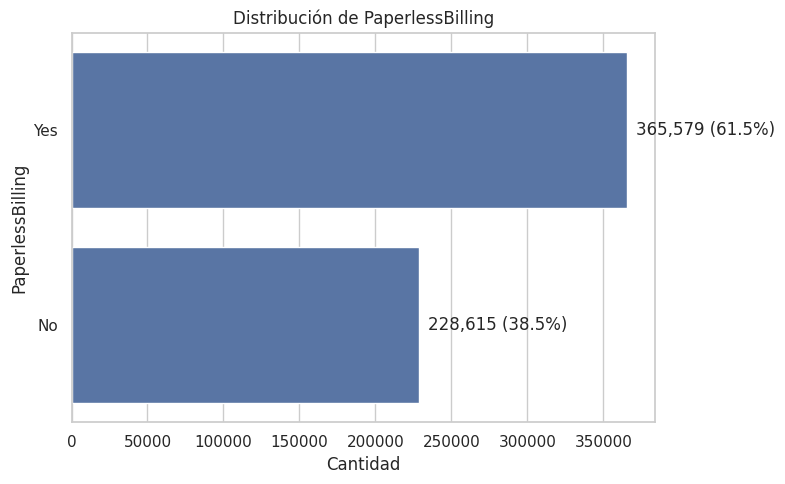

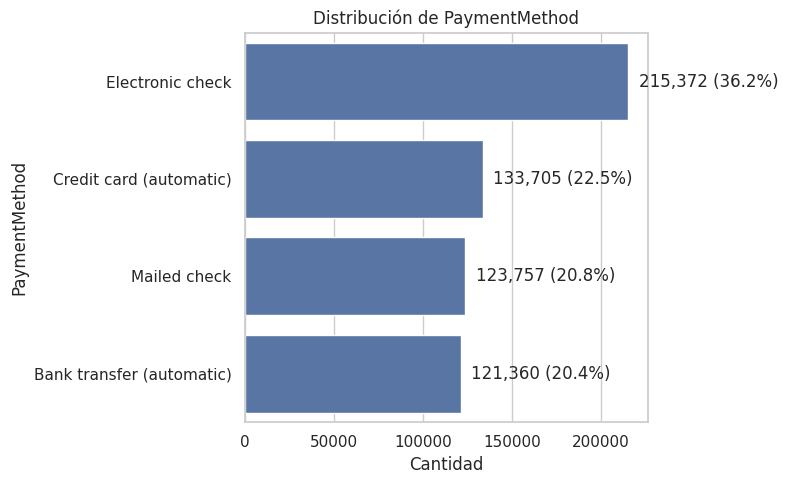

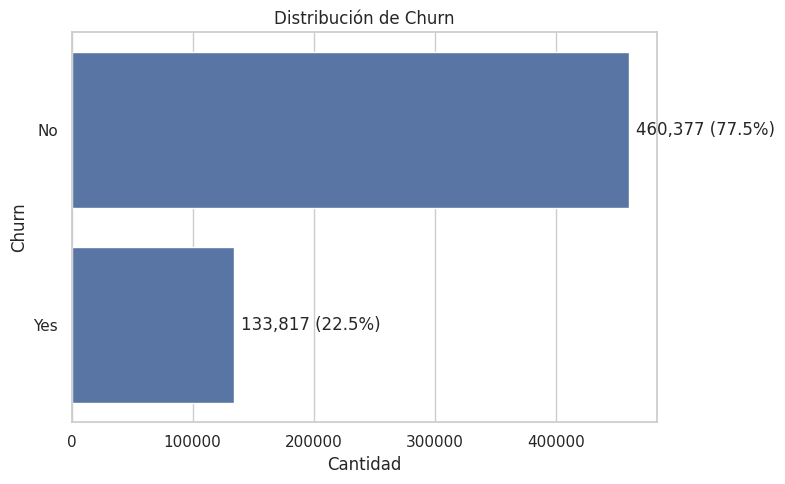

In [39]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))

    # Conteo
    counts = df[col].value_counts()
    total = len(df)

    # Crear barplot horizontal
    ax = sns.barplot(x=counts.values, y=counts.index)

    # Agregar labels con % y count
    for i, v in enumerate(counts.values):
        pct = (v / total) * 100
        ax.text(v + (total * 0.01), i, f'{v:,} ({pct:.1f}%)', va='center')

    plt.title(f'Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Observaciones de Variables Categóricas

* **Churn:** Se observa un fuerte desbalance en las clases, notando que el 22.5% de la población corresponde a clientes que abandonan el servicio brindado.
* **PaymentMethod:** El método de pago con mayor uso es **Electronic Check**, pero la utilización de los otros canales de pago (**Credit Card (automatic)**, **Bank Transfer**, **Mailed Check**) da indicios de que tenemos clientes que pertenecen a una población menos madura.
* **PaperlessBilling:** Más del 60% de los clientes tienen facturación digital. Sería interesante analizar el comportamiento de esta variable frente al **Churn**.
* **Contract:** Más del 50.3% de los clientes utilizan contratación mes a mes, lo que sugiere que son productos de suscripción. También se observa que el 31.5% de la clientela tiene un contrato de 2 años, indicando que podrían ser empresas.
* **StreamingMovies:** Esta variable confirma claramente que es una población relativamente joven. También levanta sospechas el hecho de que el 23.7% no tiene servicio de internet.
* **DeviceProtection:** Este servicio no es muy demandado, solo el 37.7% de la población lo tiene, mientras que el 23.7% muestra que no tiene internet.
* **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, InternetService:** Todas estas variables tienen algo en común que es una constante interesante: el 23.7% de su población no tiene suscrito el servicio de internet. Esto da a entender que existe una parte de la población que carece del servicio base, o bien, es una población madura que no presenta necesidad de este.
* **PhoneService:** El 94% de la población presenta servicio de teléfono.
* **gender:** La distribución entre géneros es normal y balanceada.
* **MultipleLines:** Más del 46% de los clientes poseen múltiples líneas de servicio contratado. Sería bueno analizar esta distribución con respecto a **Churn**.

# Analisis bivariado.

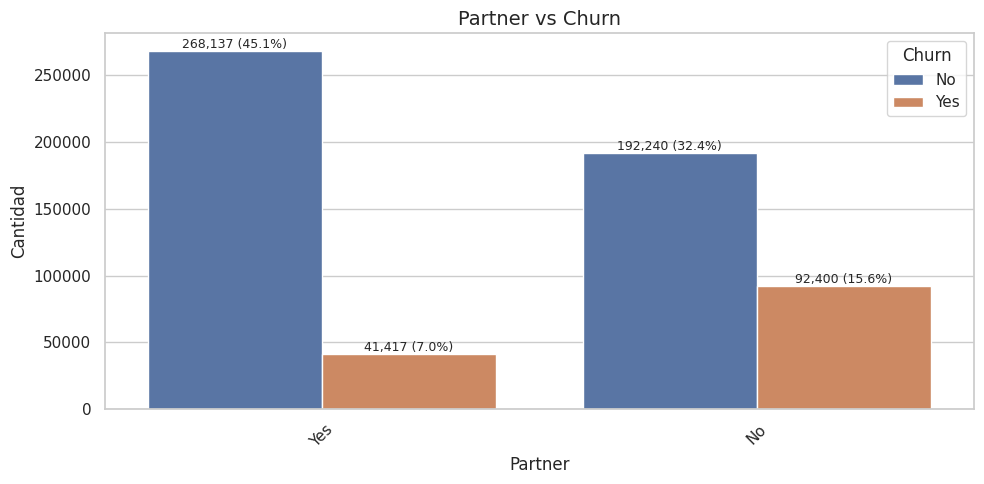

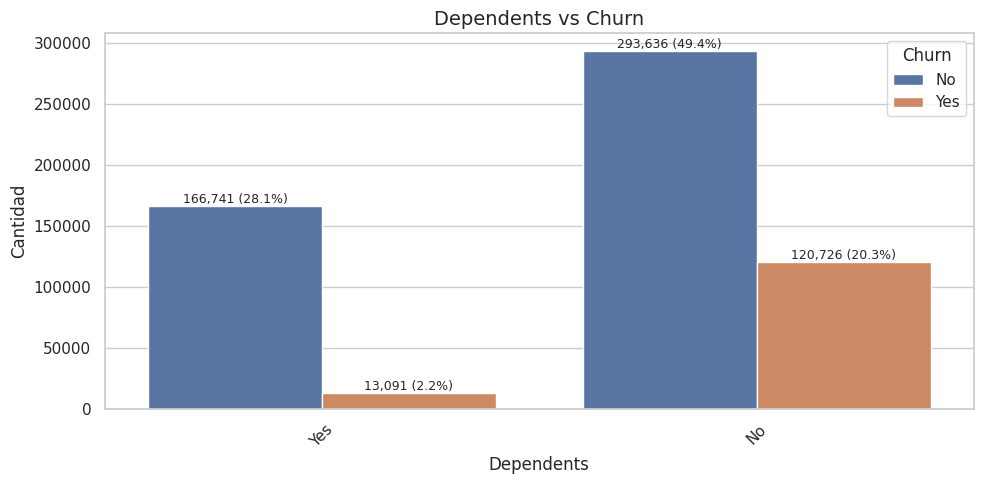

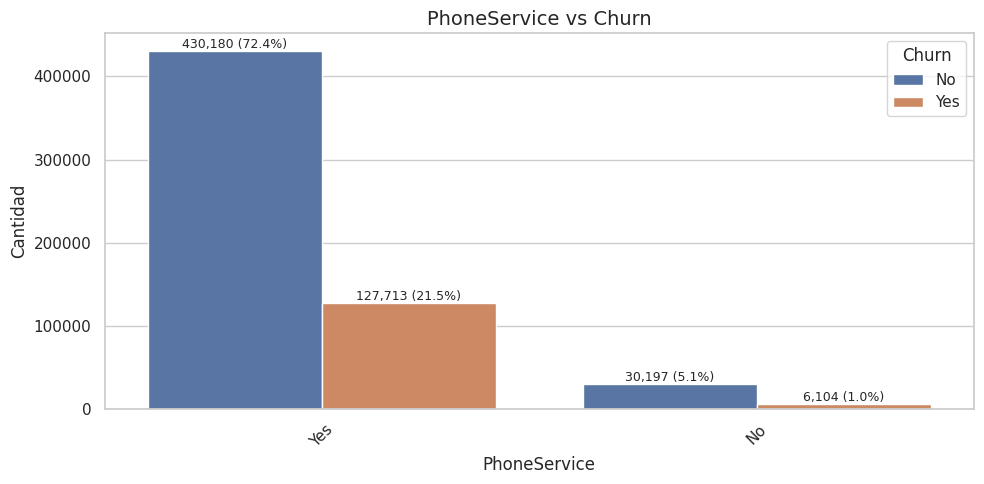

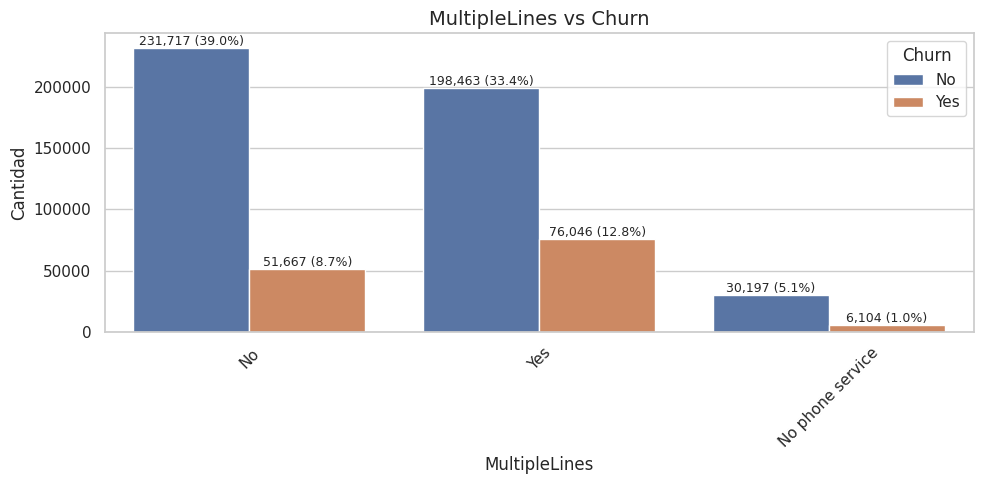

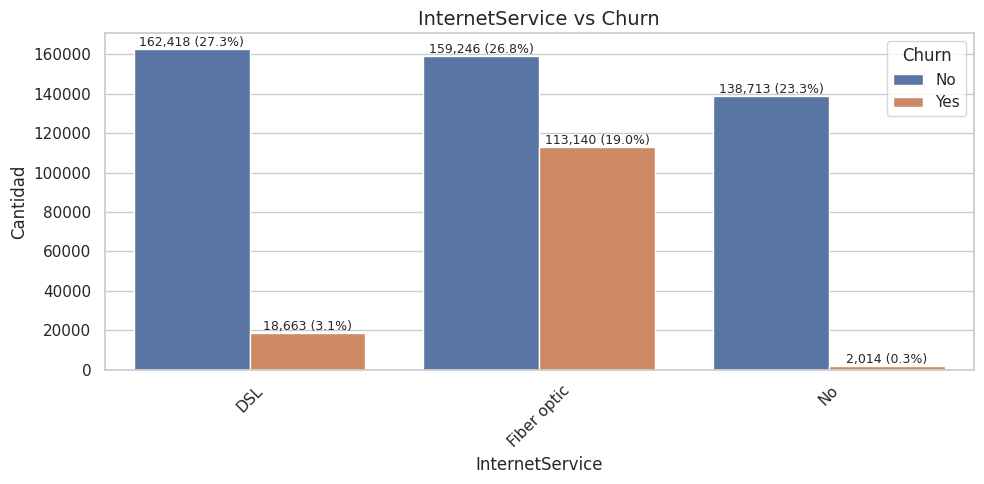

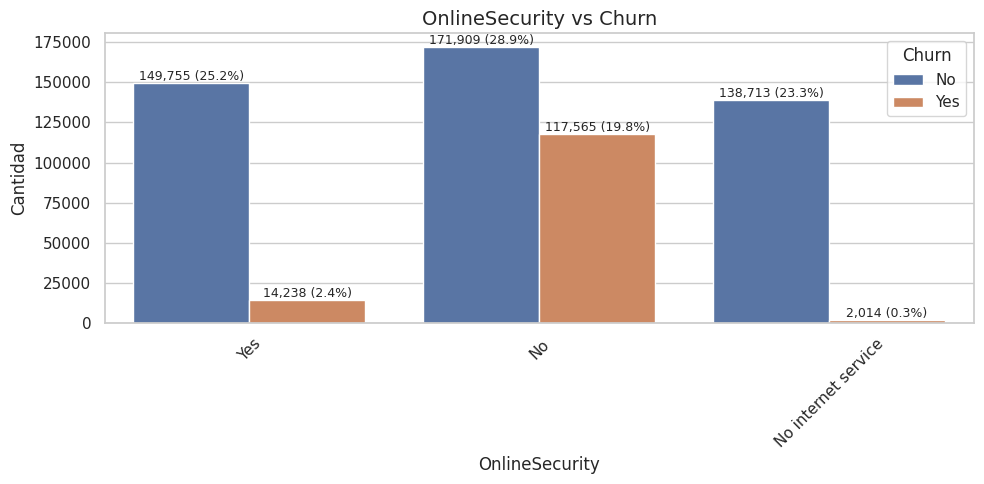

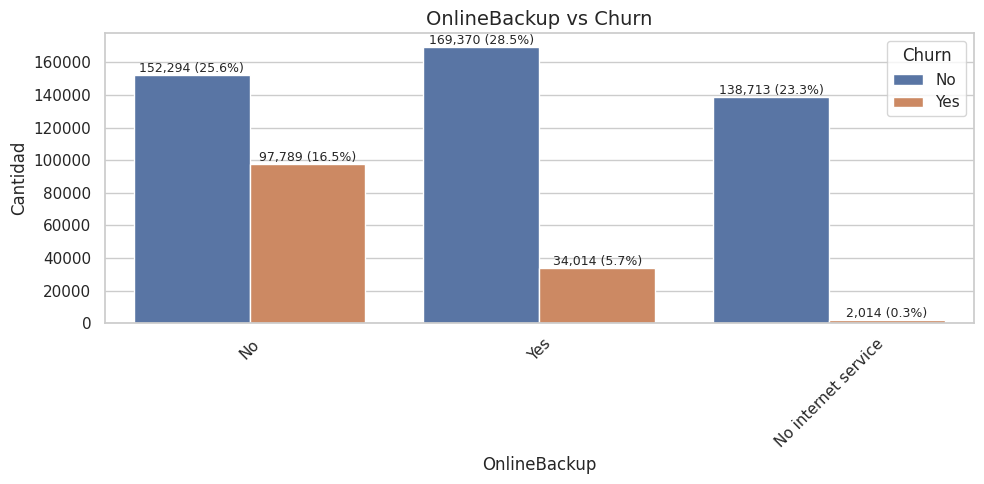

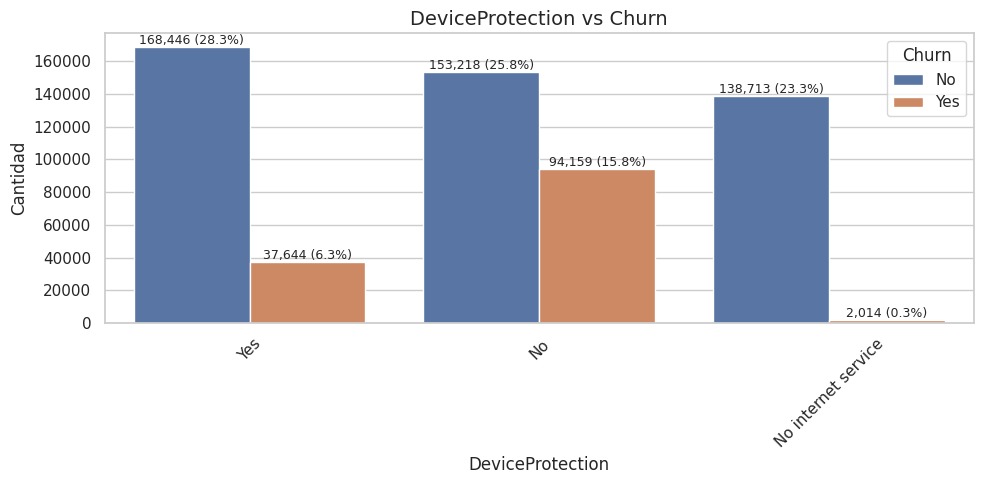

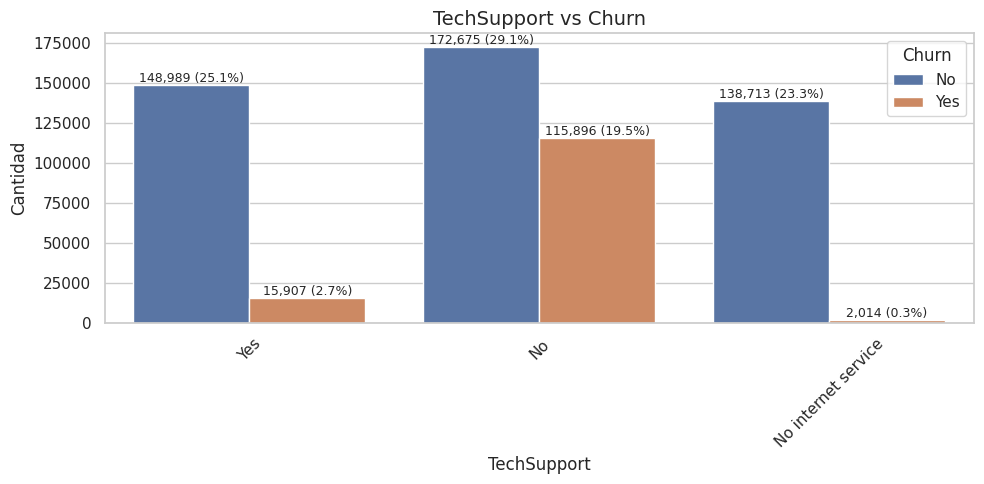

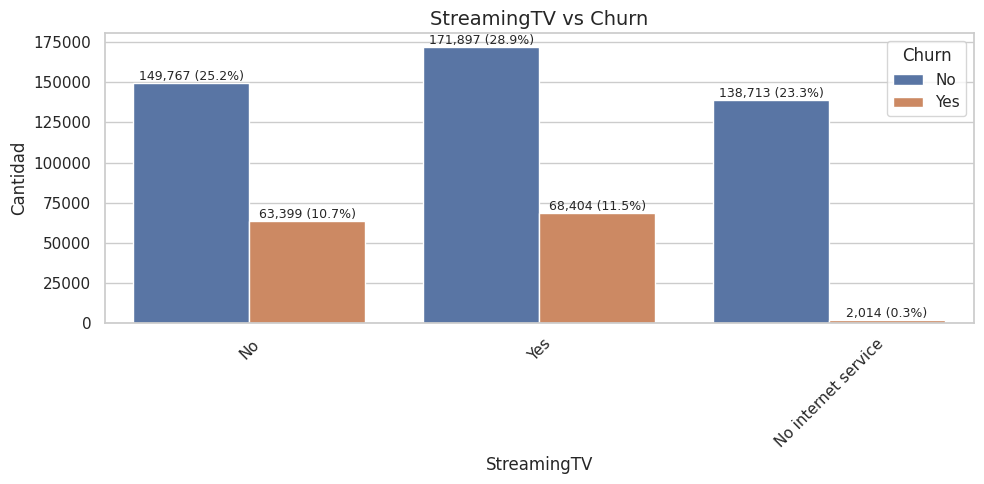

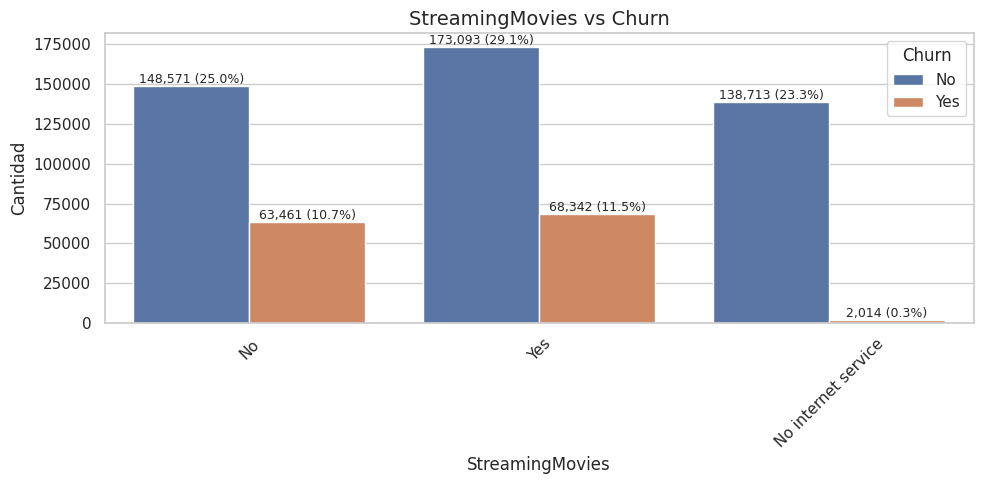

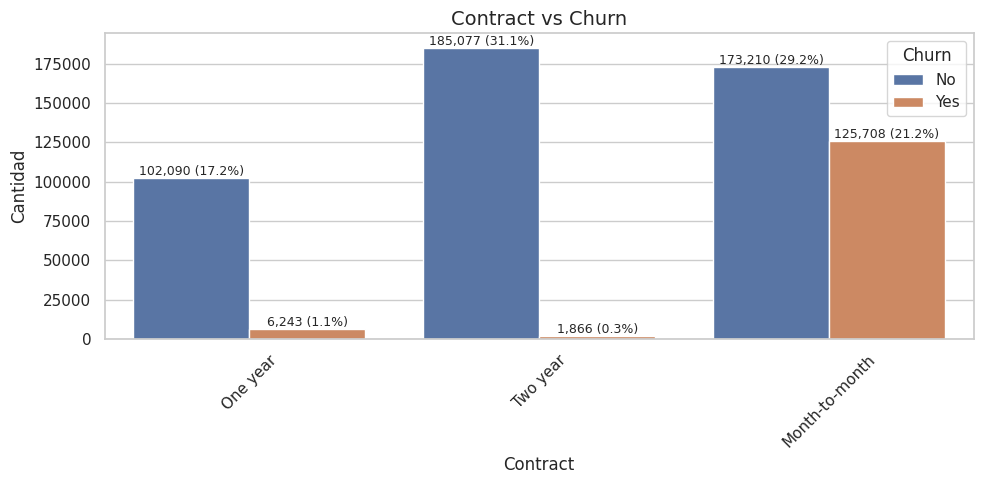

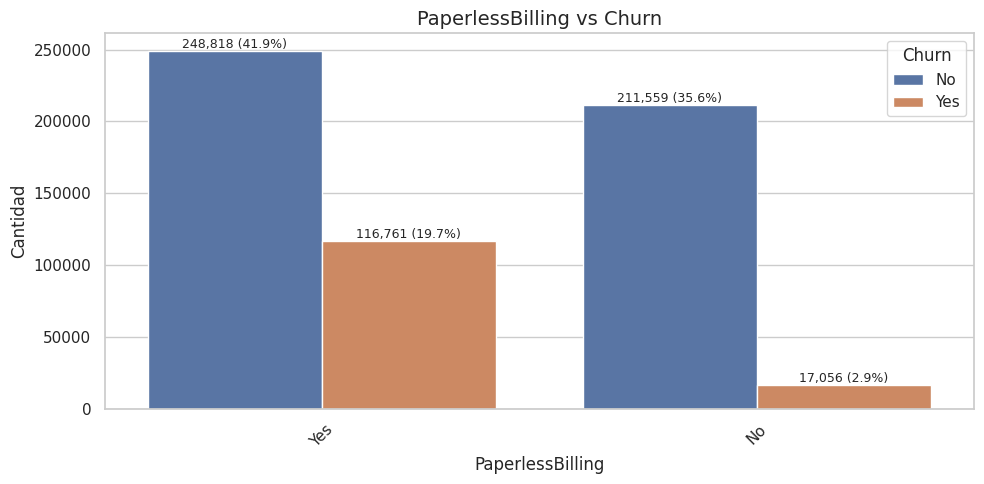

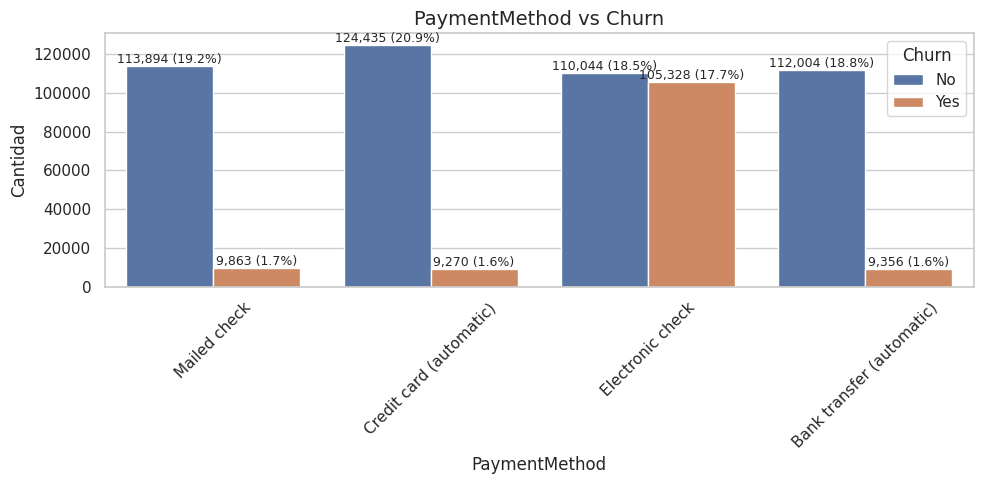

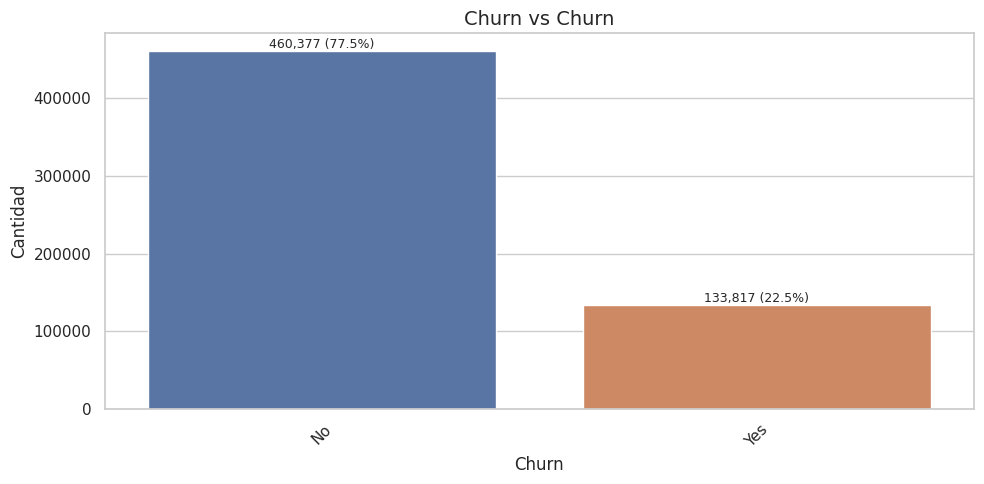

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_cols:
    plt.figure(figsize=(10,5))

    ax = sns.countplot(x=col, hue='Churn', data=df)

    total = len(df)

    # recorrer cada grupo de barras
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height == 0:
                continue
            pct = (height / total) * 100

            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{int(height):,} ({pct:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f'{col} vs Churn', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Cantidad')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()